<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Crop yield prediction: Exploratory Data Analysis

######This notebook explores FAO/Kaggle crop yield dataset which covers over 101 countries, 10 crop types uder 24 years (1990 - 2013). We examine the target distribution, numeric features, crop/country breakdowns, and correlations to build intuition before cleaning and modellling.

#1.Import and Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

sns.set_style('whitegrid')
%matplotlib inline

from google.colab import files
uploaded = files.upload()


Saving yield_df.csv to yield_df.csv


In [5]:
df = pd.read_csv('yield_df.csv')
print ('loaded data shape: ', df.shape)
df.head()

loaded data shape:  (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


#2.Data Set Overview

We inspect the shape, data types, basic statistics, duplicate rows, and missing values to understand the structure before any transformations.

In [6]:
print('shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Describe:')
print(df.describe)
df.describe(include='all').round(2)


shape: (28242, 8)

Data types:
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Describe:
<bound method NDFrame.describe of        Unnamed: 0      Area            Item  Year  hg/ha_yield  \
0               0   Albania           Maize  1990        36613   
1               1   Albania        Potatoes  1990        66667   
2               2   Albania     Rice, paddy  1990        23333   
3               3   Albania         Sorghum  1990        12500   
4               4   Albania        Soybeans  1990         7000   
...           ...       ...             ...   ...          ...   
28237       28237  Zimbabwe     Rice, paddy  2013        22581   
28238       28238  Zimbabwe         Sorghum  2013     

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00,28242,28242,28242.00,28242.00,28242.00,28242.00,28242.00
unique,NaN,101,10,NaN,NaN,NaN,NaN,NaN
top,NaN,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,NaN,4048,4276,NaN,NaN,NaN,NaN,NaN
mean,14120.50,NaN,NaN,2001.54,77053.33,1149.06,37076.91,20.54
std,8152.91,NaN,NaN,7.05,84956.61,709.81,59958.78,6.31
min,0.00,NaN,NaN,1990.00,50.00,51.00,0.04,1.30
25%,7060.25,NaN,NaN,1995.00,19919.25,593.00,1702.00,16.70
50%,14120.50,NaN,NaN,2001.00,38295.00,1083.00,17529.44,21.51
75%,21180.75,NaN,NaN,2008.00,104676.75,1668.00,48687.88,26.00


In [7]:
print('duplicate rows:', df.duplicated().sum())
print()
print('Missing Values per Column:')
print(df.isnull().sum())
print()
print('Unique Areas(Countries):', df['Area'].nunique())
print('Unique items(Crops):', df['Item'].nunique())
print('Year range:', df['Year'].min(),'-',df['Year'].max())

duplicate rows: 0

Missing Values per Column:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Unique Areas(Countries): 101
Unique items(Crops): 10
Year range: 1990 - 2013


#3.Target Variable Distribution

hg/ha yield (Hectograms of crops per hectare) is ouyr regression target. We examine it's distribution with a histogram and a boxplot to check for for skewness and outliers before modelling.

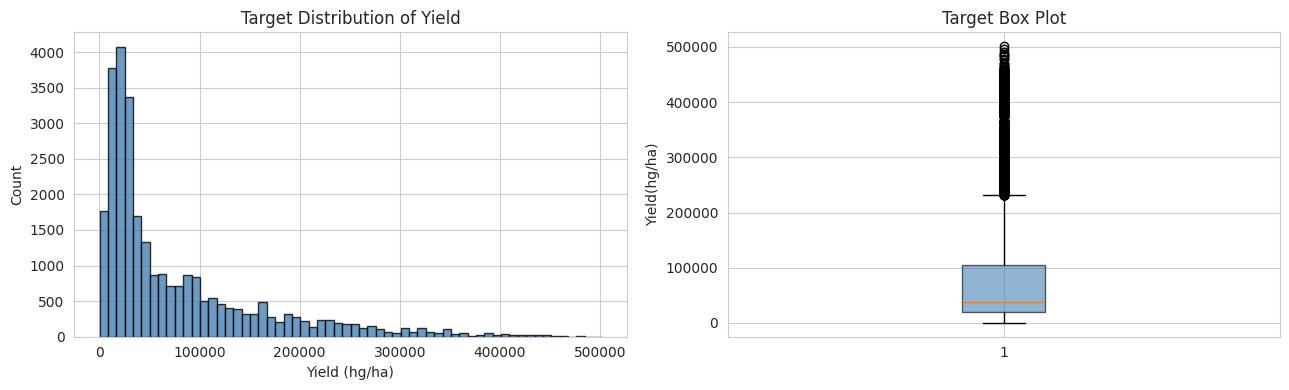

Mean Yield: 77053
Median Yield: 38295
Skewness: 2
Kurtosis: 3.066


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['hg/ha_yield'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution of Yield')

axes[1].boxplot(df['hg/ha_yield'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Yield(hg/ha)')
axes[1].set_title('Target Box Plot')

plt.tight_layout()
plt.show()

print(f"Mean Yield: {df['hg/ha_yield'].mean():.0f}")
print(f"Median Yield: {df['hg/ha_yield'].median():.0f}")
print(f"Skewness: {df['hg/ha_yield'].skew():.0f}")
print(f"Kurtosis: {df['hg/ha_yield'].kurtosis():.3f}")

#4.Univariate Analysis - Numeric Features

We look at the distribution of each numeric predictor - Average_rain_fall_mm_per_year, pesticides_tonnes, avg_temp, and year - Using Histograms and boxplots to spot skewness and outliers.

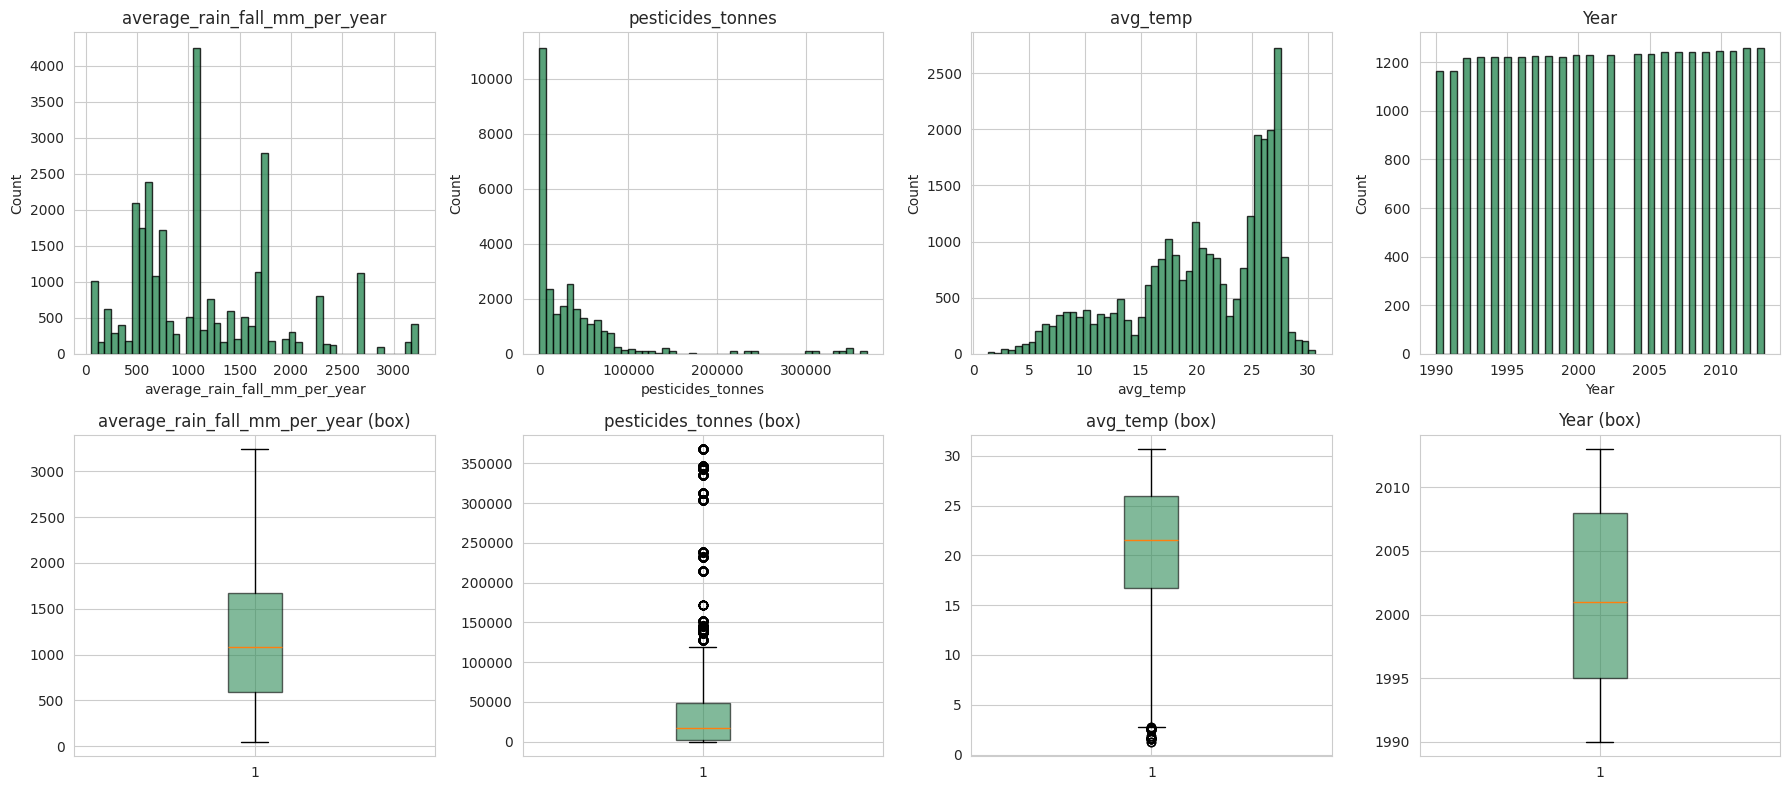

In [9]:
num_features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_features):
  axes[0, i].hist(df[col], bins=48, color='seagreen', edgecolor='black', alpha=0.8)
  axes[0, i].set_title(f'{col}')
  axes[0, i].set_xlabel(col)
  axes[0, i].set_ylabel('Count')

  axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='seagreen', alpha=0.6))
  axes[1, i].set_title(f'{col} (box)')


plt.tight_layout()
plt.show()

#5.Bivariate Analysis

We explore how each numeric feature relates to crop yield via scatter plots, then compare yields distributions across the 10 crop types and identify the top-yielding countries.

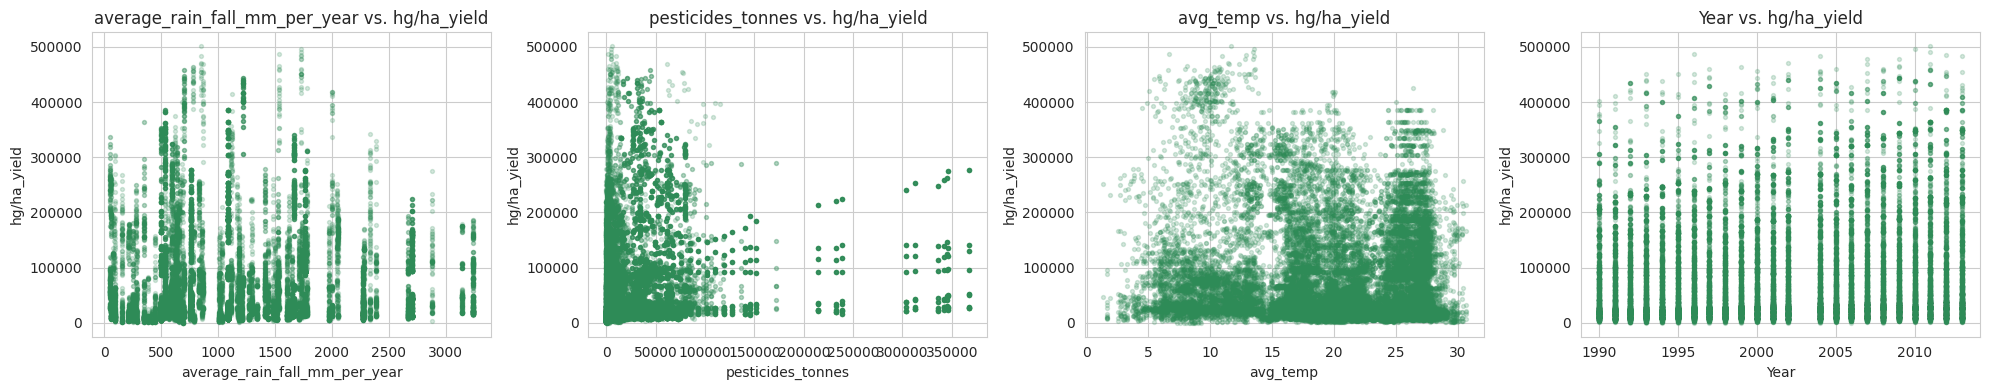

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(num_features):
  axes[i].scatter(df[col], df['hg/ha_yield'], alpha=0.2, s=8, color='seagreen')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('hg/ha_yield')
  axes[i].set_title(f'{col} vs. hg/ha_yield')

plt.tight_layout()
plt.show()

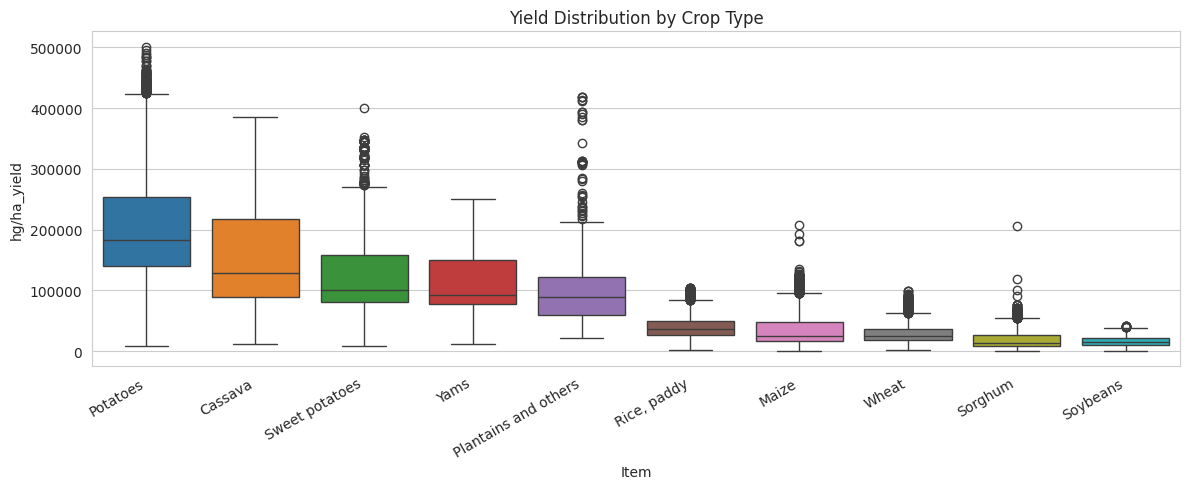

In [11]:
# Yield by Crop type
plt.figure(figsize=(12, 5))
order = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False).index
sns.boxplot(x='Item', y='hg/ha_yield', data=df, order=order, palette='tab10')
plt.xticks(rotation=30, ha='right')
plt.title('Yield Distribution by Crop Type')
plt.tight_layout()
plt.show()

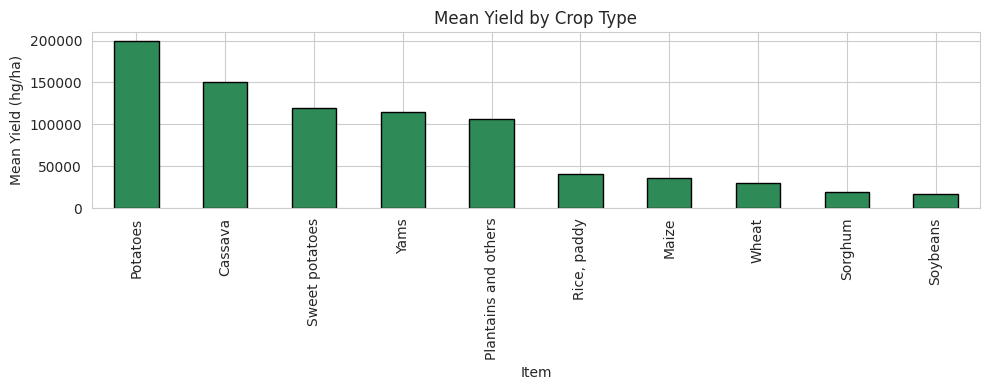

Item
Potatoes                199802.0
Cassava                 150479.0
Sweet potatoes          119058.0
Yams                    114140.0
Plantains and others    106041.0
Rice, paddy              40730.0
Maize                    36310.0
Wheat                    30116.0
Sorghum                  18636.0
Soybeans                 16731.0


In [12]:
# Mean yield per crop type (bar)
mean_by_crop = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
mean_by_crop.plot(kind='bar', title='Mean Yield by Crop Type', color='seagreen', edgecolor='black')
plt.ylabel('Mean Yield (hg/ha)')
plt.tight_layout()
plt.show()
print(mean_by_crop.round(0).to_string())

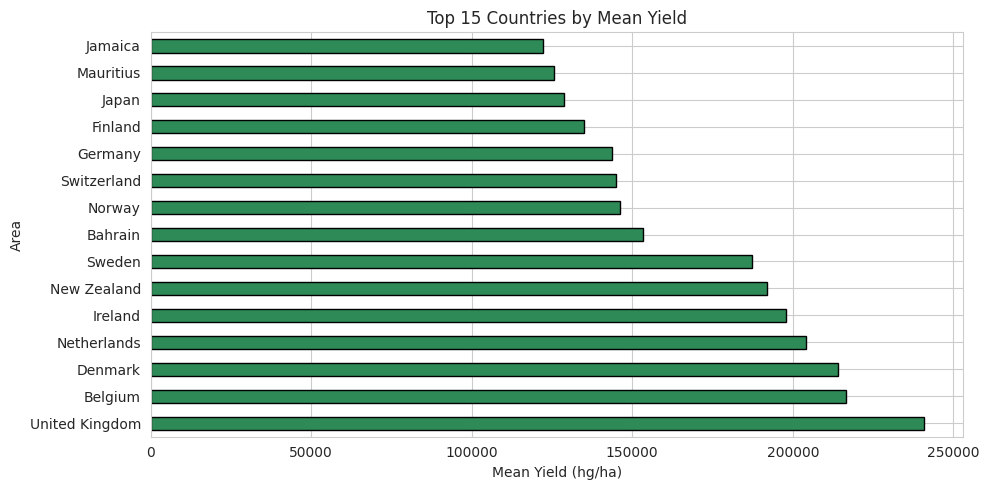

In [13]:
# Top 15 Countries by mean Yield
mean_by_country = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
mean_by_country.plot(kind='barh', title='Top 15 Countries by Mean Yield', color='seagreen', edgecolor='black')
plt.xlabel('Mean Yield (hg/ha)')
plt.tight_layout()
plt.show()

#6.Correlation Analysis

A heatmap of the numeric features(including the target) reveals linear relationships. Because Area and Item are categorical, they are excluded here, their impact appears in the bivariate scetion above.

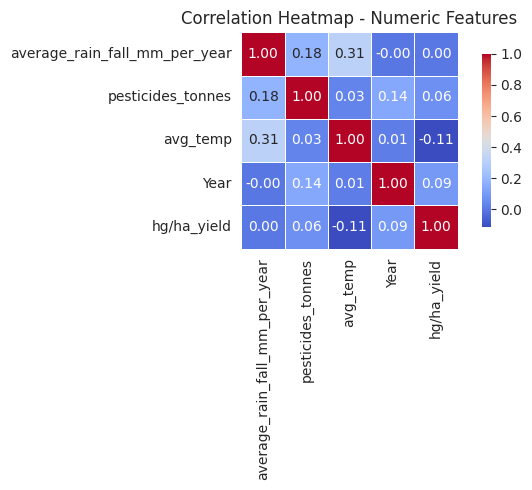


Correlations with hg/ha_yield:
Year                             0.091630
pesticides_tonnes                0.064085
average_rain_fall_mm_per_year    0.000962
avg_temp                        -0.114777
Name: hg/ha_yield, dtype: float64


In [14]:
num_df = df[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year', 'hg/ha_yield']]
corr = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

print('\nCorrelations with hg/ha_yield:')
print(corr['hg/ha_yield'].drop('hg/ha_yield').sort_values(ascending=False))

#7.Domain Deep-Dive

We investigate three domain-specific questions: which crops achieve the highest maximum yields, which countries lead per crop, and how global average yield has trended over the 24-year period.

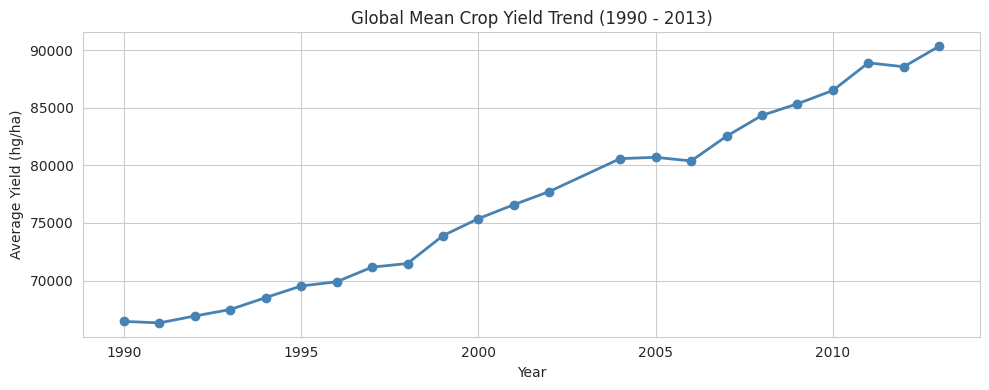

In [18]:
# yield trend over the years
yearly = df.groupby('Year')['hg/ha_yield'].mean().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(yearly['Year'], yearly['hg/ha_yield'], marker='o', color='steelblue', linewidth=2)
plt.title('Global Mean Crop Yield Trend (1990 - 2013)')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()

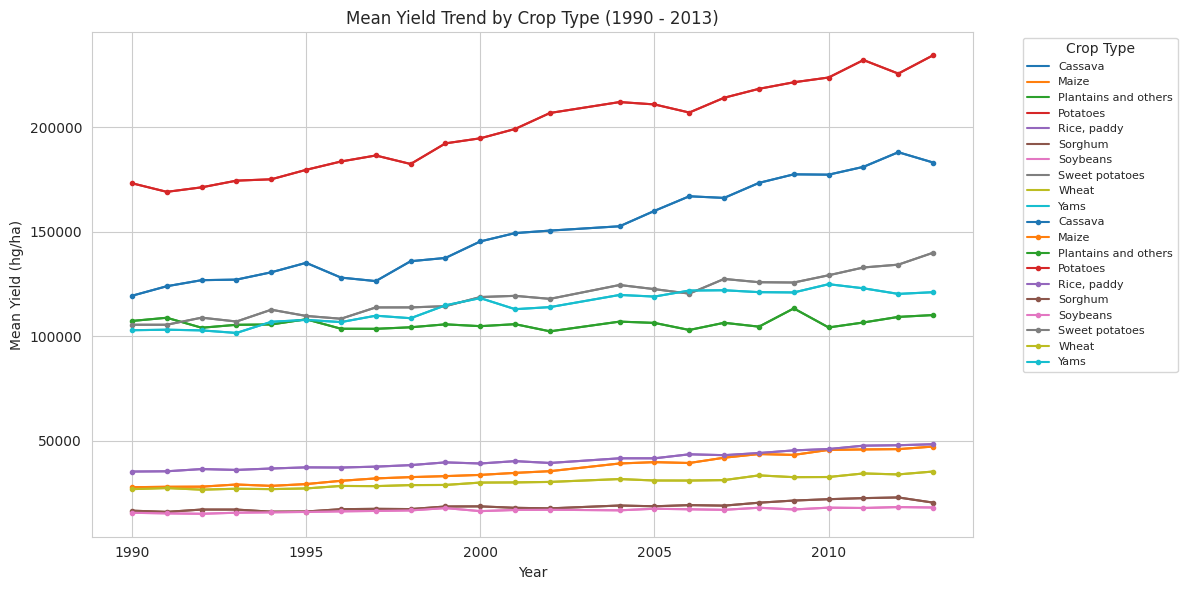

In [19]:
# Yield Trend by Crop Type
pivot = df.groupby(['Year', 'Item'])['hg/ha_yield'].mean().unstack()
pivot.plot(kind='line', figsize=(12, 6))
for col in pivot.columns:
  plt.plot(pivot.index, pivot[col], marker='o', linewidth=1.5, markersize=3, label=col)
plt.title('Mean Yield Trend by Crop Type (1990 - 2013)')
plt.xlabel('Year')
plt.ylabel('Mean Yield (hg/ha)')
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
#Top Country per crop
top_per_crop = df.groupby(['Item', 'Area'])['hg/ha_yield'].mean().reset_index()
top_per_crop = top_per_crop.loc[top_per_crop.groupby('Item')['hg/ha_yield'].idxmax()]
top_per_crop = top_per_crop.sort_values('hg/ha_yield', ascending=False).reset_index(drop=True)
print(top_per_crop.to_string(index=False))

                Item      Area   hg/ha_yield
            Potatoes   Belgium 448891.538462
Plantains and others Guatemala 291096.304348
             Cassava     India 282234.434783
      Sweet potatoes     Egypt 261369.347826
                Yams     Japan 211343.434783
               Maize     Qatar 136593.000000
         Rice, paddy     Egypt  89234.695652
               Wheat   Belgium  84988.615385
             Sorghum   Austria  63873.250000
            Soybeans     Italy  34446.695652


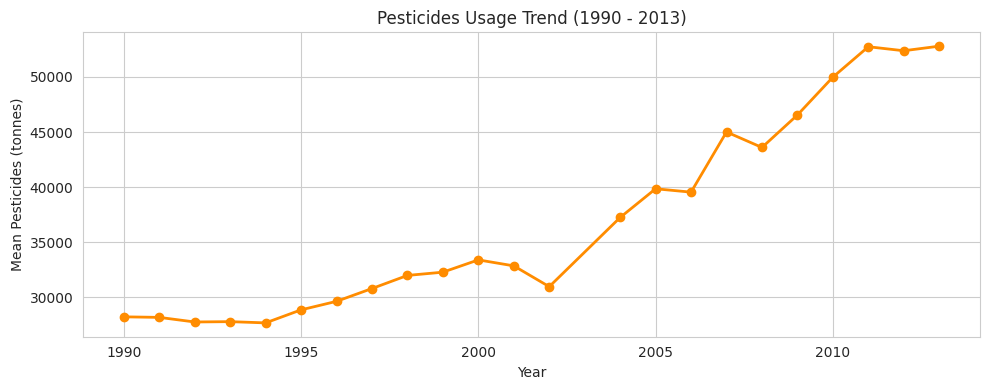

In [21]:
# Pesticide usage trend over years
pest_yearly = df.groupby('Year')['pesticides_tonnes'].mean()
plt.figure(figsize=(10, 4))
pest_yearly.plot(marker='o', color='darkorange', linewidth=2)
plt.title('Pesticides Usage Trend (1990 - 2013)')
plt.xlabel('Year')
plt.ylabel('Mean Pesticides (tonnes)')
plt.grid(True)
plt.tight_layout()
plt.show()

#8.Summary of Key Findings

The table below distills the most important observations from the EDA into a concise reference for the cleaning and modelling steps that follow.

In [22]:
summary = pd.DataFrame({
   'Finding': [
       'Daraset Size',
       'Target Skewness',
       'No missing values',
       'Highest-yield crop',
       'Lowest-yield',
       'Top-yield',
       'Yield Trend',
       'Pesticide trend',
       'Strongest numeric correlation',
   ],

   'Detail': [
       f"{df.shape[0]:,} rows x {df.shape[1]} columns, 101 countries, 10 crops, 1990-2013",
       f"Skew = {df['hg/ha_yield'].skew():.2f} - Right-Skewed; log-transform could help",
       'No nulls in any column',
       'No exact duplicate rows',
       f"{df.groupby('Item')['hg/ha_yield'].mean().idxmax()} ({df.groupby('Item')['hg/ha_yield'].mean().max():.0f} hg/ha)",
       f"{df.groupby('Item')['hg/ha_yield'].mean().idxmin()} ({df.groupby('Item')['hg/ha_yield'].mean().min():.0f} hg/ha)",
       f"{df.groupby('Area')['hg/ha_yield'].mean().idxmax()}",
        'Steady upward trend from 1990 to 2013',
       f"avg_temp (r = {df['hg/ha_yield'].corr(df['avg_temp']):.2f}), but crop type dominates",
   ]
})
summary

,Finding,Detail
0,Daraset Size,"28,242 rows x 8 columns, 101 countries, 10 cro..."
1,Target Skewness,Skew = 1.79 - Right-Skewed; log-transform coul...
2,No missing values,No nulls in any column
3,Highest-yield crop,No exact duplicate rows
4,Lowest-yield,Potatoes (199802 hg/ha)
5,Top-yield,Soybeans (16731 hg/ha)
6,Yield Trend,United Kingdom
7,Pesticide trend,Steady upward trend from 1990 to 2013
8,Strongest numeric correlation,"avg_temp (r = -0.11), but crop type dominates"
